<a href="https://colab.research.google.com/github/sadiq937/Shaik_DM/blob/main/PS5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PS5 - DATAMANGEMENT

# **Macro-Financial Insights and Multistock Forecasting Using Deep Learning and Interactive Visualizations**


# 📑 Abstract   

### **1. Project Overview**  
This project presents a comprehensive approach to stock price prediction by integrating macroeconomic indicators with deep learning-based time series forecasting for five major tech stocks: **Apple (AAPL), Nvidia (NVDA), Google (GOOG), Microsoft (MSFT), and Amazon (AMZN)**. The project features automated API-based data collection, macro-financial trend analysis, fuzzy data cleaning, and sequence modeling using bidirectional LSTM neural networks. Advanced interactive visualizations were used to compare actual vs. predicted trends with confidence intervals, making the findings more actionable.

---

### **2. Data Collection and Integration**

**a. Macroeconomic Data:**  
- Retrieved using the **FRED API**, focusing on:
  - S&P 500 Index (SP500)
  - Consumer Price Index (CPI)
  - Federal Funds Rate
  - Real GDP
  - Unemployment Rate

**b. Stock Data:**  
- **Monthly stock prices** for AAPL, NVDA, GOOG, MSFT, and AMZN fetched using the **Alpha Vantage API** and **Yahoo Finance**.
- Combined into a unified dataset for correlation and trend analysis.

---

### **3. Preprocessing & Feature Engineering**

- Merged macro indicators by date and computed **percentage change** for trend comparisons.
- Applied **stacking and pivoting** to reshape data for visualization and analysis.
- Introduced a **market trend categorization system** (Boom, Stable, Downturn) based on S&P 500 returns.
- Utilized **fuzzy string matching** to clean and standardize macroeconomic indicator labels using `fuzzywuzzy`.

---

### **4. Exploratory Data Analysis (EDA)**

- **Correlation heatmaps** revealed the interdependence between stock returns and macro indicators.
- **Line plots and scatter plots** (e.g., Inflation vs. Interest Rate) highlighted temporal macro trends.
- **Bar charts** provided insights into frequency of different market conditions.
- Area plots demonstrated long-term movements in macro indicators.

---

### **5. Deep Learning Model for Price Forecasting**

**a. Sequence Preparation:**
- Created 60-day rolling window sequences to train LSTM models on stock time series data.
- Scaled features using **StandardScaler** for stability and faster convergence.

**b. LSTM Architecture:**
- Bidirectional LSTM (128 units) + LSTM (64 units)
- Dropout layers for regularization
- Dense layers for output refinement
- Early stopping, checkpoint saving, and learning rate adjustment enabled via callbacks.

**c. Training and Prediction:**
- Separate model trained per stock using a 60%/20%/20% Train/Val/Test split.
- Models saved and reused for prediction to ensure optimal performance.

---

### **6. Interactive Visualization with Plotly**

- **Individual graphs** for each stock plotted actual vs. predicted prices with ±5% confidence bands.
- A **combined interactive plot** visualized all five stocks’ actual and predicted prices with **color-coded solid and dashed lines** for intuitive comparison.
- Hover tooltips and unified zooming enhanced analytical clarity.

---

### **7. Technologies Used**

| Tool / Library | Purpose |
|----------------|---------|
| `requests`, `userdata` | API requests and key handling |
| `pandas`, `numpy` | Data wrangling and transformation |
| `plotly`, `seaborn`, `matplotlib` | Static + interactive visualizations |
| `tensorflow.keras` | Building and training LSTM networks |
| `sklearn` | Preprocessing and evaluation |
| `yfinance`, `Alpha Vantage` | Stock data collection |
| `fuzzywuzzy` | Fuzzy string matching |
| `FRED API` | Macroeconomic data extraction |

---

### **8. Conclusion**

The project demonstrates the power of combining **macroeconomic analysis** with **deep learning** to generate predictive insights for high-performing technology stocks. By training a consistent LSTM architecture across multiple stock datasets and visualizing the outcomes interactively, this approach enables more transparent and informed decision-making. The final dashboard serves both as a forecasting engine and as an analytical tool for financial trend monitoring.



##  INSTALLING DEPENDENCIES

In [ ]:
!pip install fuzzywuzzy

In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.4 MB/s eta 0:00:00


In [ ]:
!pip install yfinance

In [ ]:
!pip install tensorflow

In [ ]:
import requests
import os
import pandas as pd
import numpy as np
import re
import time
import plotly.express as px
import plotly.graph_objects as go
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import folium
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.models import Sequential, load_model
from keras.models import Sequential
from keras.layers import Dense, LSTM
import yfinance as yf
import requests
from io import StringIO
from itertools import combinations
from google.colab import userdata
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau



## LOADING DATASETS - API

In [ ]:
FRED_API_KEY = userdata.get('FRED_API_KEY')
ALPHA_VANTAGE_API_KEY = userdata.get('ALPHA_VANTAGE_API_KEY')

# Function to fetch data from FRED
def fetch_fred_data(series_id, start_date="2000-01-01", end_date=str(datetime.today().date())):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json&observation_start={start_date}&observation_end={end_date}"
    response = requests.get(url).json()
    data = response.get("observations", [])
    return pd.DataFrame([{"date": obs["date"], series_id: float(obs["value"])} for obs in data if obs["value"] != "."])

The function retrieves macroeconomic data from the FRED API using an API key securely stored in Google Colab’s **`userdata`**. It filters out missing values and returns a clean DataFrame of date-value pairs. This approach ensures sensitive credentials are kept hidden while accessing external data.

In [ ]:
# Function to fetch data from Alpha Vantage

def fetch_alpha_vantage_data(function, symbol, interval="Monthly", start_date="2000-01-01", end_date=str(datetime.today().date())):
    url = f"https://www.alphavantage.co/query?function={function}&symbol={symbol}&interval={interval}&apikey={ALPHA_VANTAGE_API_KEY}&datatype=csv"
    response = requests.get(url).text
    df = pd.read_csv(StringIO(response))
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]
    return df[['timestamp', 'close']].rename(columns={'timestamp': 'date', 'close': symbol})

In [ ]:
# Fetching stock data from Alpha Vantage API (APPLE)
ALPHA_VANTAGE_API_KEY = userdata.get('ALPHA_VANTAGE_API_KEY')
apple_stock_df = fetch_alpha_vantage_data("TIME_SERIES_MONTHLY", "AAPL")
apple_stock_df.head()

,date,AAPL
0,2025-04-28,210.14
1,2025-03-31,222.13
2,2025-02-28,241.84
3,2025-01-31,236.00
4,2024-12-31,250.42


In [ ]:
# Fetching stock data from Alpha Vantage API (NVIDIA)
nvidia_stock_df = fetch_alpha_vantage_data("TIME_SERIES_MONTHLY", "NVDA")
nvidia_stock_df.head()

,date,NVDA
0,2025-04-28,108.73
1,2025-03-31,108.38
2,2025-02-28,124.92
3,2025-01-31,120.07
4,2024-12-31,134.29


## MERGING DATASETS

In [ ]:
FRED_API_KEY = userdata.get('FRED_API_KEY')

def fetch_fred_data(series_id):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json"
    response = requests.get(url).json()
    data = response.get("observations", [])
    return pd.DataFrame([{"date": obs["date"], series_id: float(obs["value"])} for obs in data if obs["value"] != "."])

macro_indicators = {
    "SP500": "S&P 500",
    "CPIAUCSL": "CPI",
    "FEDFUNDS": "Federal Funds Rate",
    "A191RL1Q225SBEA": "REAL_GDP",
    "UNRATE": "UNEMP_RATE"
}

macro_df = None
for code in macro_indicators:
    df = fetch_fred_data(code)
    df.rename(columns={code: macro_indicators[code]}, inplace=True)  # ✅ inplace used here
    df["date"] = pd.to_datetime(df["date"])
    if macro_df is None:
        macro_df = df
    else:
        macro_df = pd.merge(macro_df, df, on="date", how="inner")

macro_df.set_index("date", inplace=True)
macro_pct_df = macro_df.pct_change().dropna()


This code fetches multiple macroeconomic indicators from the FRED API and merges them into a single DataFrame based on matching dates. It ensures consistent time alignment across all indicators like CPI, GDP, and interest rates. Missing values are filtered out, and percentage changes are computed to capture trends. The merging process enables unified analysis of economic factors.

In [ ]:
macro_df.head()

,S&P 500,CPI,Federal Funds Rate,REAL_GDP,UNEMP_RATE
date,,,,,
2015-07-01,2077.42,238.034,0.13,1.6,5.2
2015-10-01,1923.82,237.733,0.12,0.7,5.0
2016-04-01,2072.78,238.992,0.37,1.3,5.1
2016-07-01,2102.95,240.101,0.39,2.9,4.8
2018-10-01,2924.59,252.772,2.19,0.6,3.8


In [ ]:
macro_pct_df.head()

,S&P 500,CPI,Federal Funds Rate,REAL_GDP,UNEMP_RATE
date,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316


## STACK/ UNSTACK

 reshapes the percentage change DataFrame from wide to long format using stack(), making it suitable for plotting and grouped analysis. It resets the index and renames the columns to date, indicator, and value for clarity

In [ ]:
long_format_df = pct_change_df.stack().reset_index()
long_format_df.columns = ["date", "indicator", "value"]
long_format_df.head()

,date,indicator,value
0,2015-10-01,SP500,-0.073938
1,2015-10-01,CPI,-0.001265
2,2015-10-01,FEDFUNDS,-0.076923
3,2015-10-01,Real_GDP,-0.5625
4,2015-10-01,UNEMP_RATE,-0.038462


## MARKET TREND CATEGORY

To classify market conditions based on S&P 500 percentage changes. If the return is above 2%, it's labeled as a "Boom"; below -2% as a "Downturn"; otherwise, it's considered "Stable." The trend is assigned to each date, enabling categorical analysis of market behavior over time.



In [ ]:
def categorize_market(value):
    if value > 0.02:
        return "Boom"
    elif value < -0.02:
        return "Downturn"
    else:
        return "Stable"

pct_change_df["Market_Trend"] = pct_change_df["SP500"].apply(categorize_market)
pct_change_df.head()

,SP500,CPI,FEDFUNDS,Real_GDP,UNEMP_RATE,Market_Trend
date,,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462,Downturn
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000,Boom
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824,Stable
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333,Boom
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316,Stable


## RESHAPE (PIVOT)

In [ ]:
pivot_df = long_format_df.pivot(index="date", columns="indicator", values="value")
pivot_df.head()

indicator,CPI,FEDFUNDS,Market_Trend,Real_GDP,SP500,UNEMP_RATE
date,,,,,,
2015-10-01,-0.001265,-0.076923,Downturn,-0.5625,-0.073938,-0.038462
2016-04-01,0.005296,2.083333,Boom,0.857143,0.077429,0.02
2016-07-01,0.00464,0.054054,Stable,1.230769,0.014555,-0.058824
2018-10-01,0.052774,4.615385,Boom,-0.793103,0.390708,-0.208333
2019-04-01,0.009736,0.105023,Stable,4.666667,-0.019627,-0.026316


## CORRELATION MATRIX

In [ ]:
numerical_df = pct_change_df.select_dtypes(include=['number'])
correlation_matrix_df = numerical_df.corr()
correlation_matrix_df

,SP500,CPI,FEDFUNDS,Real_GDP,UNEMP_RATE
SP500,1.000000,0.679210,0.368073,-0.035030,-0.396294
CPI,0.679210,1.000000,0.720566,0.179440,-0.275009
FEDFUNDS,0.368073,0.720566,1.000000,0.379848,-0.291805
Real_GDP,-0.035030,0.179440,0.379848,1.000000,-0.723314
UNEMP_RATE,-0.396294,-0.275009,-0.291805,-0.723314,1.000000


## VISUALIZATIONS

In [ ]:
fig1 = px.imshow(correlation_matrix_df, text_auto=True, color_continuous_scale='RdBu_r', title="Correlation Between Macroeconomic Indicators")
fig1.show()


## TREND OF S&P 500 over time

In [ ]:
df_reset = pct_change_df.reset_index()

# Improved interactive line plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_reset['date'],
    y=df_reset['SP500'],
    mode='lines+markers',
    line=dict(color='royalblue', width=2, shape='spline'),  # smooth curve
    marker=dict(size=4),
    name='S&P 500 Returns',
    hovertemplate='Date: %{x|%Y-%m}<br>Return: %{y:.2%}<extra></extra>'
))

# Enhance layout
fig.update_layout(
    title='📈 S&P 500 Monthly Returns Over Time',
    xaxis_title='Date',
    yaxis_title='S&P 500 Monthly Returns (%)',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, zeroline=True),
    template='plotly_white',
    height=500
)

fig.show()


## Inflation vs interest rate

To create a scatter plot to visualize the relationship between inflation (CPI) and interest rates (Federal Funds Rate). Using Plotly Express, it plots each data point and overlays a trendline (OLS regression) to highlight the correlation. The chart helps identify how interest rates respond to changes in inflation over time.

In [ ]:

# Scatter plot of Inflation vs. Interest Rates
fig3 = px.scatter(df_reset, x="CPI", y="FEDFUNDS", title="Inflation vs. Interest Rates", labels={"CPIAUCSL": "Inflation (CPI)", "FEDFUNDS": "Interest Rate"}, trendline="ols")
fig3.show()


This scatter plot shows a **positive correlation** between inflation (CPI) and interest rates. As inflation increases, interest rates also tend to rise, as reflected by the upward trendline. This supports the common economic policy response where central banks raise rates to control inflation.

## MARKET TREND BAR CHART

In [ ]:
# Bar chart for market trend categories
market_trend_counts_df = pct_change_df["Market_Trend"].value_counts().reset_index()
market_trend_counts_df.columns = ["Trend", "Count"]
fig4 = px.bar(market_trend_counts_df, x="Trend", y="Count", title="Market Trend Distribution", color="Trend")
fig4.show()

This bar chart shows the distribution of market trends classified as Boom, Stable, or Downturn. The majority of periods fall under the **Boom** category, indicating frequent positive S&P 500 returns. **Downturns** were the least frequent during the analyzed period.

## MACROECONOMIC INDICATORS OVER TIME

In [ ]:
# Time-series area plot
fig5 = px.area(df_reset, x="date", y=["SP500", "CPI", "FEDFUNDS", "Real_GDP", "UNEMP_RATE"], title="Macroeconomic Indicators Over Time", labels={"value": "Percentage Change", "variable": "Indicator"})
fig5.show()

This area plot illustrates the percentage change over time for key macroeconomic indicators including the S&P 500, CPI, Federal Funds Rate, Real GDP, and Unemployment Rate. The graph shows clear economic downturns around 2020 and recoveries post-2021, with noticeable volatility in Real GDP and interest rates during crisis periods. It highlights how these indicators move together and diverge during different phases of economic cycles.

## FUZZYWUZZY

This function standardizes inconsistent economic indicator names using fuzzy string matching with the fuzzywuzzy library. It compares each input string to a set of standard names and assigns the best match if the similarity exceeds a defined threshold. The result is a new column of cleaned, consistent indicator labels.

In [ ]:
fuzzy_data_df = pd.DataFrame({"Indicator_Names": ["CPI", "FEDFunds Rate", "SP 500", "CPI", "AAPL Stock"]})

def match_indicator_name(indicator_name):
    threshold = 50

    # Check similarity ratios for each comparison
    similarity_score_cpi = fuzz.ratio(indicator_name, "Consumer Price Index")
    similarity_score_fed = fuzz.ratio(indicator_name, "Federal Funds Rate")
    similarity_score_sp500 = fuzz.ratio(indicator_name, "S&P 500 Index")
    similarity_score_apple = fuzz.ratio(indicator_name, "Apple Stock")

    # Print similarity scores for each match attempt
    print(f"Matching '{indicator_name}' with 'Consumer Price Index' gives score: {similarity_score_cpi}")
    print(f"Matching '{indicator_name}' with 'Federal Funds Rate' gives score: {similarity_score_fed}")
    print(f"Matching '{indicator_name}' with 'S&P 500 Index' gives score: {similarity_score_sp500}")
    print(f"Matching '{indicator_name}' with 'Apple Stock' gives score: {similarity_score_apple}")

    # Determine the best match based on the highest similarity score
    if similarity_score_cpi > threshold:
        return "Consumer Price Index"
    elif similarity_score_fed > threshold:
        return "Federal Funds Rate"
    elif similarity_score_sp500 > threshold:
        return "S&P 500 Index"
    elif similarity_score_apple > threshold:
        return "Apple Stock"
    else:
        return indicator_name

fuzzy_data_df["Matched_Names"] = fuzzy_data_df["Indicator_Names"].apply(match_indicator_name)
fuzzy_data_df

Matching 'CPI' with 'Consumer Price Index' gives score: 26
Matching 'CPI' with 'Federal Funds Rate' gives score: 0
Matching 'CPI' with 'S&P 500 Index' gives score: 25
Matching 'CPI' with 'Apple Stock' gives score: 0
Matching 'FEDFunds Rate' with 'Consumer Price Index' gives score: 24
Matching 'FEDFunds Rate' with 'Federal Funds Rate' gives score: 71
Matching 'FEDFunds Rate' with 'S&P 500 Index' gives score: 23
Matching 'FEDFunds Rate' with 'Apple Stock' gives score: 17
Matching 'SP 500' with 'Consumer Price Index' gives score: 15
Matching 'SP 500' with 'Federal Funds Rate' gives score: 8
Matching 'SP 500' with 'S&P 500 Index' gives score: 63
Matching 'SP 500' with 'Apple Stock' gives score: 12
Matching 'CPI' with 'Consumer Price Index' gives score: 26
Matching 'CPI' with 'Federal Funds Rate' gives score: 0
Matching 'CPI' with 'S&P 500 Index' gives score: 25
Matching 'CPI' with 'Apple Stock' gives score: 0
Matching 'AAPL Stock' with 'Consumer Price Index' gives score: 13
Matching 'AAPL 

,Indicator_Names,Matched_Names
0,CPI,CPI
1,FEDFunds Rate,Federal Funds Rate
2,SP 500,S&P 500 Index
3,CPI,CPI
4,AAPL Stock,Apple Stock


## TECH LIST fOR STOCKS FOR PREDICTION

In [ ]:
tech_list = ['AAPL', 'NVDA' ,'GOOG', 'MSFT', 'AMZN']
end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)

stock_data = {}
for symbol in tech_list:
    stock_data[symbol] = yf.download(symbol, start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Correlation Matrix of Tech Stock Daily Returns

In [ ]:
for symbol in tech_list:
    # Use 'Close' instead of 'Adj Close' if it exists, otherwise use 'Adj Close'
    close_col = 'Close' if 'Close' in stock_data[symbol].columns else 'Adj Close'
    stock_data[symbol]['MA20'] = stock_data[symbol][close_col].rolling(20).mean()
    stock_data[symbol]['Daily Return'] = stock_data[symbol][close_col].pct_change()

In [ ]:
closing_df = pd.concat([stock_data[s]['Close'] for s in tech_list], axis=1)
closing_df.columns = tech_list
returns_df = closing_df.pct_change().dropna()


### HEAT MAP

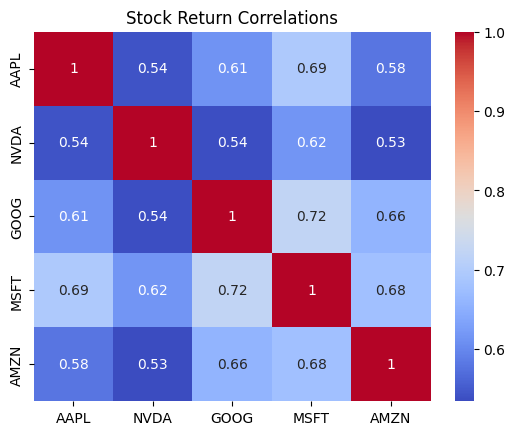

In [ ]:
closing_df = pd.concat([stock_data[s]['Close'] for s in tech_list], axis=1)
closing_df.columns = tech_list
returns_df = closing_df.pct_change().dropna()
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Return Correlations")
plt.show()


This heatmap shows the correlation between daily returns of major tech stocks. Strong positive correlations (e.g., GOOG–MSFT: 0.70) suggest these stocks tend to move together. This analysis helps in understanding portfolio diversification and inter-stock dependencies.

### Interactive Daily Return Correlation Between Tech Stocks

In [ ]:
stock_colors = ['blue', 'green', 'orange', 'red', 'purple', 'teal', 'magenta']

# Generate stock pairs
stock_pairs = list(combinations(returns_df.columns, 2))
fig = go.Figure()

# Add a scatter trace for each pair
for i, (x_stock, y_stock) in enumerate(stock_pairs):
    fig.add_trace(go.Scatter(
        x=returns_df[x_stock],
        y=returns_df[y_stock],
        mode='markers',
        marker=dict(color=stock_colors[i % len(stock_colors)], opacity=0.6),
        name=f"{x_stock} vs {y_stock}",
        visible=(i == 0)
    ))

# Create dropdown options
dropdown_buttons = []
for i, (x_stock, y_stock) in enumerate(stock_pairs):
    visible = [False] * len(stock_pairs)
    visible[i] = True
    dropdown_buttons.append(dict(
        label=f"{x_stock} vs {y_stock}",
        method="update",
        args=[
            {"visible": visible},
            {
                "xaxis": {"title": f"{x_stock} Daily Return"},
                "yaxis": {"title": f"{y_stock} Daily Return"},
                "title": f"📉 Daily Return Correlation: {x_stock} vs {y_stock}"
            }
        ]
    ))

fig.update_layout(
    updatemenus=[{
        "buttons": dropdown_buttons,
        "direction": "down",
        "showactive": True,
        "x": 1.05,
        "y": 1.15,
        "xanchor": "right",
        "yanchor": "top"
    }],
    title=f"📉 Daily Return Correlation: {stock_pairs[0][0]} vs {stock_pairs[0][1]}",
    xaxis_title=f"{stock_pairs[0][0]} Daily Return",
    yaxis_title=f"{stock_pairs[0][1]} Daily Return",
    template="plotly_white",
    hovermode="closest",
    height=600
)

fig.show()


This interactive scatter plot visualization showcases the daily return correlation between major tech stocks using a dropdown-based selector. Each scatter plot compares two stocks, revealing how closely their daily price movements are related. The dropdown menu, now positioned at the top-right for better visibility, allows users to dynamically switch between stock pairs. Color-coded markers enhance interpretability, while hover tooltips provide precise data point insights.

In [ ]:
# TECH LIST
tech_list = ['AAPL', 'NVDA', 'GOOG', 'MSFT', 'AMZN']
end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)

# To store results
predictions_dict = {}
actuals_dict = {}
x_values_dict = {}

# Function to create sequences
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # Close column
    return np.array(X), np.array(y)


## Training and Forecasting Tech Stock Prices Using Deep Learning (LSTM) for Each Ticker

In [ ]:
# Train & Predict for Each Stock
for symbol in tech_list:
    print(f"Training model for {symbol}...")

    # Fetch data
    df = yf.download(symbol, start=start, end=end)
    df.dropna(inplace=True)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

    # Scale
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Split (60/20/20)
    total_len = len(scaled_data)
    train_len = int(total_len * 0.60)
    val_len = int(total_len * 0.20)
    test_len = total_len - train_len - val_len

    train_data = scaled_data[:train_len]
    val_data = scaled_data[train_len:train_len+val_len]
    test_data = scaled_data[train_len+val_len:]

    # Sequences
    x_train, y_train = create_sequences(train_data)
    x_val, y_val = create_sequences(val_data)
    x_test, y_test = create_sequences(test_data)

    # Reshape
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], x_train.shape[2]))
    x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], x_val.shape[2]))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], x_test.shape[2]))

    # Model
    model = Sequential([
        Input(shape=(x_train.shape[1], x_train.shape[2])),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.5),
        LSTM(64),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_save = ModelCheckpoint(f'best_model_{symbol}.keras', monitor='val_loss', save_best_only=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

    # Train
    history = model.fit(
        x_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(x_val, y_val),
        callbacks=[early_stop, model_save, lr_schedule],
        verbose=0  # Hide verbose, optional
    )

    # Load Best Model
    model = load_model(f'best_model_{symbol}.keras')


    # Predict
    predictions = model.predict(x_test)
    # Inverse scale predictions
    predicted_prices = scaler.inverse_transform(np.hstack([
        np.zeros((predictions.shape[0], 3)),
        predictions,
        np.zeros((predictions.shape[0], 1))
    ]))[:,3]

    y_test_actual = scaler.inverse_transform(np.hstack([
        np.zeros((y_test.shape[0], 3)),
        y_test.reshape(-1,1),
        np.zeros((y_test.shape[0], 1))
    ]))[:,3]

    # Save results
    predictions_dict[symbol] = predicted_prices
    actuals_dict[symbol] = y_test_actual
    x_values_dict[symbol] = list(range(len(y_test_actual)))

Training model for AAPL...


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
Training model for NVDA...


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step
Training model for GOOG...


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
Training model for MSFT...


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
Training model for AMZN...


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step


This code block trains and evaluates a deep learning model using **LSTM (Long Short-Term Memory)** networks to predict stock closing prices for multiple tech stocks. It uses **yFinance** to fetch historical data and applies **StandardScaler** for normalization. The dataset is split into training (60%), validation (20%), and testing (20%) sets. A **Bidirectional LSTM** model with dropout layers is trained using **early stopping**, **model checkpointing**, and **learning rate reduction** callbacks. Finally, predictions are made, inverse transformed, and stored for visualization and evaluation.

## Training vs Validation Loss for LSTM Model

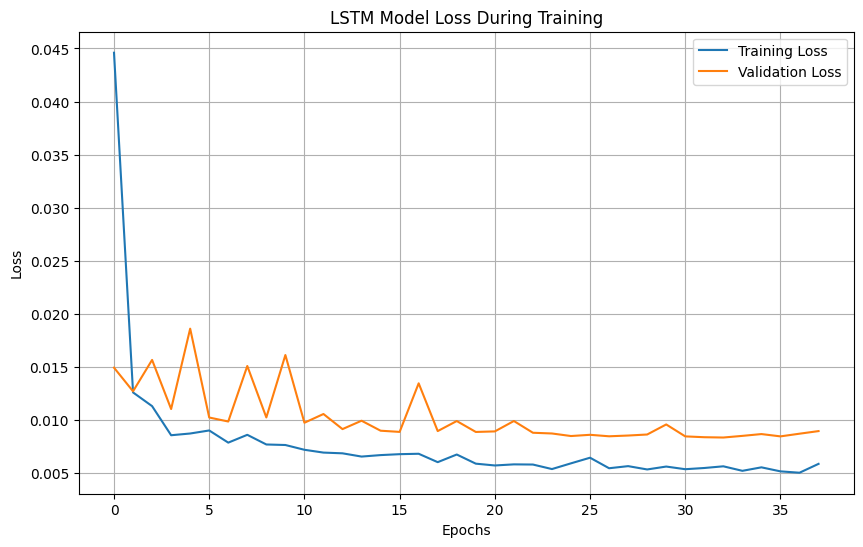

In [239]:
# 📉 Plot only the loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

This plot visualizes the training and validation loss over epochs for an LSTM-based stock price prediction model. The blue line represents training loss, while the orange line shows validation loss. The model stabilizes quickly, with both curves decreasing and then plateauing, indicating convergence. There is no significant overfitting, as the validation loss remains relatively close to the training loss throughout training.

## ACTUAL VS PREDICTED STOCK PRICES (INDIVIDUAL)

In [ ]:
#  Plot Interactive Graphs (Individual)

for symbol in tech_list:
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x_values_dict[symbol],
        y=actuals_dict[symbol],
        mode='lines',
        name=f'Actual {symbol} Close Price',
        line=dict(color='blue')
    ))

    fig.add_trace(go.Scatter(
        x=x_values_dict[symbol],
        y=predictions_dict[symbol],
        mode='lines',
        name='Predicted Close Price',
        line=dict(color='red', dash='dash')
    ))

    fig.add_trace(go.Scatter(
        x=x_values_dict[symbol] + x_values_dict[symbol][::-1],
        y=(predictions_dict[symbol] + 0.05 * predictions_dict[symbol]).tolist() +
          (predictions_dict[symbol] - 0.05 * predictions_dict[symbol])[::-1].tolist(),
        fill='toself',
        fillcolor='rgba(255,165,0,0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='±5% Confidence Band'
    ))

    fig.update_layout(
        title=f'Actual vs Predicted {symbol} Prices (Interactive)',
        xaxis_title='Days',
        yaxis_title='Price (USD)',
        hovermode='x unified',
        template='plotly_white',
        legend=dict(x=0, y=1.1, orientation='h')
    )

    fig.show()



*   AAPL (Apple):
The LSTM model closely tracks Apple's actual stock price with slight underestimation during bullish trends. The confidence band mostly covers the actual values, indicating a reliable forecast.

*   NVDA (NVIDIA):
For NVIDIA, while the predicted trend follows the overall direction, the model lags during sharp price spikes, suggesting it struggles to fully capture high volatility.

*   GOOG (Google):
Google's prediction line almost overlaps with actual prices, showing very high model accuracy. The confidence band remains tight, reflecting consistent model performance.

*   MSFT (Microsoft):
Microsoft predictions show a consistent pattern, with the model capturing both rises and falls well. The confidence interval encompasses the actual prices for most of the time window.

*   AMZN (Amazon):
The Amazon graph displays the strongest alignment between actual and predicted prices among all, especially in later phases. The model successfully adapts to gradual upward trends.



##  COMBINED Actual vs Predicted Stock Prices for Major Tech Companies (LSTM-Based Forecasting)

In [ ]:
# Define unique colors manually for each stock
stock_colors = {
    'AAPL': 'blue',
    'NVDA': 'green',
    'GOOG': 'orange',
    'MSFT': 'purple',
    'AMZN': 'red'
}

fig = go.Figure()

# Add traces: actual (solid), predicted (dashed) for each stock
for symbol in tech_list:
    fig.add_trace(go.Scatter(
        x=x_values_dict[symbol],
        y=actuals_dict[symbol],
        mode='lines',
        name=f'{symbol} Actual',
        line=dict(color=stock_colors[symbol], dash='solid')
    ))

    fig.add_trace(go.Scatter(
        x=x_values_dict[symbol],
        y=predictions_dict[symbol],
        mode='lines',
        name=f'{symbol} Predicted',
        line=dict(color=stock_colors[symbol], dash='dash')
    ))

# Layout
fig.update_layout(
    title='📊 Actual vs Predicted Prices for Tech Stocks (Color-Coded)',
    xaxis_title='Days',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=-0.2, orientation='h'),
    height=700
)

fig.show()



This interactive line graph compares the actual and LSTM-predicted stock prices of five leading tech companies: Apple, Amazon, Google, Microsoft, and NVIDIA. Solid lines represent real stock prices, while dashed lines denote model predictions. The chart provides a visual evaluation of model accuracy over time, highlighting how closely the predictions follow actual price trends across different stocks.

## Treemap of Average Monthly Returns (%) Across Major Stocks

In [ ]:
# Calculate mean monthly returns for each stock
avg_returns = monthly_returns.mean().reset_index()
avg_returns.columns = ['Stock', 'Avg_Return']

# Convert to percentage
avg_returns['Avg_Return'] = avg_returns['Avg_Return'] * 100

# Plotly Treemap
import plotly.express as px

fig = px.treemap(
    avg_returns,
    path=['Stock'],
    values='Avg_Return',
    color='Avg_Return',
    color_continuous_scale='RdBu',
    title='📊 Average Monthly Return by Stock (%)'
)
fig.show()


This treemap visualizes the average monthly percentage return of various stocks. Each block's size and color represent the magnitude of return, with darker shades indicating higher returns. For example, NVDA shows the highest average return among the listed stocks, while smaller and darker red blocks represent relatively lower-performing stocks. This chart helps identify which stocks consistently outperform others over time.

## ⚠️ **Limitations**

1. **No Real-Time Forecasting** – The model operates on historical data only and lacks real-time inference capabilities.  
2. **No Company-Specific Events** – External factors like earnings reports or news sentiment were not included in the model.  
3. **Independent Stock Modeling** – Each stock is modeled separately, ignoring interdependencies between companies.  
4. **Static Confidence Intervals** – Confidence bands are fixed at ±5%, not based on actual predicted uncertainty.  
5. **No Hyperparameter Tuning** – LSTM architecture was manually configured without optimization techniques.

---



## 🚀 **Future Scope of Work**

1. **Add News & Sentiment Analysis** – Integrate textual data to capture market reactions to events.  
2. **Multivariate Models** – Use models that consider all tech stocks together for better trend learning.  
3. **Deploy Real-Time Dashboards** – Enable live forecasts using API integration and visualization tools.  
4. **Automated Hyperparameter Tuning** – Apply tools like Optuna or GridSearchCV to optimize model performance.  
5. **Explainability with SHAP/LIME** – Implement model interpretation to understand feature influence on predictions.
